<a href="https://colab.research.google.com/github/RishabhXYZA/Stock-Market-Predictor-/blob/main/Stock_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [ ]:
start='2012-01-01'
end='2024-12-31'

stock='GOOG'
data=yf.download(stock,start,end)

/tmp/ipython-input-2929008702.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(stock,start,end)
[*********************100%***********************]  1 of 1 completed


In [ ]:
data.reset_index(inplace=True)

In [ ]:
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOG,GOOG,GOOG,GOOG,GOOG
0,2012-01-03,16.475201,16.543042,16.152336,16.166451,147611217
1,2012-01-04,16.546257,16.595034,16.356600,16.465789,114989399
2,2012-01-05,16.316736,16.439543,16.247905,16.393986,131808205
3,2012-01-06,16.094151,16.341249,16.088455,16.320203,108119746
4,2012-01-09,15.411779,16.019378,15.381325,16.006996,233776981
...,...,...,...,...,...,...
3264,2024-12-23,195.531937,196.030768,191.182126,193.576511,15235900
3265,2024-12-24,197.108261,197.208018,194.741796,195.711524,6809800
3266,2024-12-26,196.639359,197.696879,195.412222,196.280199,7907900


In [ ]:
ma_100_days=data.Close.rolling(100).mean()

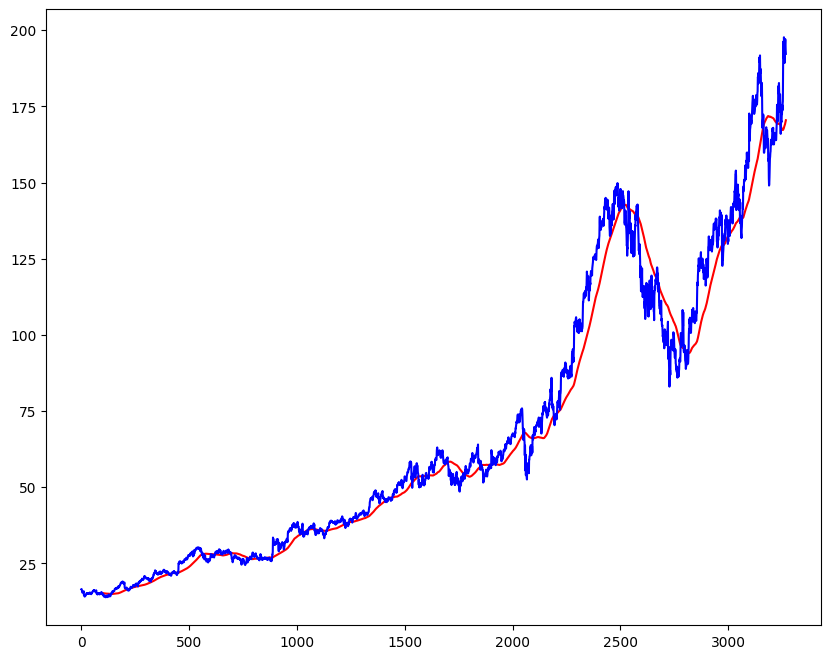

In [ ]:
plt.figure(figsize=(10,8))
plt.plot(ma_100_days,'r')
plt.plot(data.Close,'b')
plt.show()

In [ ]:
ma_200_days=data.Close.rolling(200).mean()

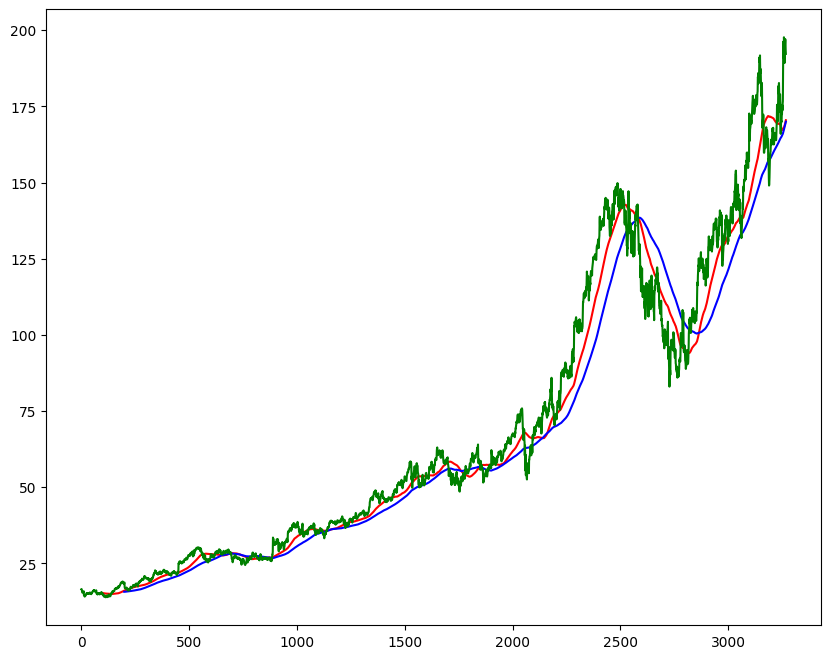

In [ ]:
plt.figure(figsize=(10,8))
plt.plot(ma_100_days,'r')
plt.plot(ma_200_days,'b')
plt.plot(data.Close,'g')
plt.show()

In [ ]:
data.dropna(inplace=True)

In [ ]:
data_train=pd.DataFrame(data.Close[0:int(len(data)*0.80)])
data_test=pd.DataFrame(data.Close[int(len(data)*0.80):len(data)])

In [ ]:
data_train.shape[0]

2615

In [ ]:
data_test.shape[0]

654

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))

In [ ]:
data_train_scale=scaler.fit_transform(data_train)

In [ ]:
x=[]
y=[]

for i in range(100,data_train_scale.shape[0]):
  x.append(data_train_scale[i-100:i])
  y.append(data_train_scale[i,0])

In [ ]:
x,y=np.array(x),np.array(y)

In [ ]:
from keras.layers import Dense,Dropout,LSTM
from keras.models import Sequential

In [ ]:
model=Sequential()
model.add(LSTM(units=50,activation='relu',return_sequences=True,
               input_shape=(x.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units=60,activation='relu',return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=80,activation='relu',return_sequences=True))
model.add(Dropout(0.4))


model.add(LSTM(units=120,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam',loss='mean_squared_error')

In [ ]:
model.fit(x,y,epochs=50,batch_size=32,verbose=1)

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 32s 311ms/step - loss: 0.0458
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 306ms/step - loss: 0.0054
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 43s 331ms/step - loss: 0.0043
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 38s 288ms/step - loss: 0.0039
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 25s 313ms/step - loss: 0.0047
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 24s 307ms/step - loss: 0.0041
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 42s 313ms/step - loss: 0.0043
Epoch 8/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 292ms/step - loss: 0.0030
Epoch 9/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 42s 304ms/step - loss: 0.0034
Epoch 10/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 43s 330ms/step - loss: 0.0029
Epoch 11/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 38s 294ms/step - loss: 0.0027
Epoch 12/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 42s 307ms/step - loss: 0.0026
Epoch 13/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 307ms/step - loss: 0.0028
Epoch 14/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 25s 321ms/step - loss: 0.0026
Epoch 15/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 24s 

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,285 (2.05 MB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 357,524 (1.36 MB)

In [ ]:
pas_100_days=data_train.tail(100)

In [ ]:
data_test=pd.concat([pas_100_days,data_test],ignore_index=True)

In [ ]:
data_test

Ticker,GOOG
0,145.139771
1,143.824600
2,144.217239
3,143.563141
4,136.840103
...,...
749,195.531937
750,197.108261
751,196.639359
752,193.586487


In [ ]:
data_test_scale=scaler.fit_transform(data_test)

In [ ]:
x=[]
y=[]

for i in range(100,data_test_scale.shape[0]):
  x.append(data_test_scale[i-100:i])
  y.append(data_test_scale[i,0])

In [ ]:
x,y=np.array(x),np.array(y)

In [ ]:
y_predict=model.predict(x)

21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step


In [ ]:
scale=1/scaler.scale_

In [ ]:
y_predict=y_predict*scale

In [ ]:
y=y*scale

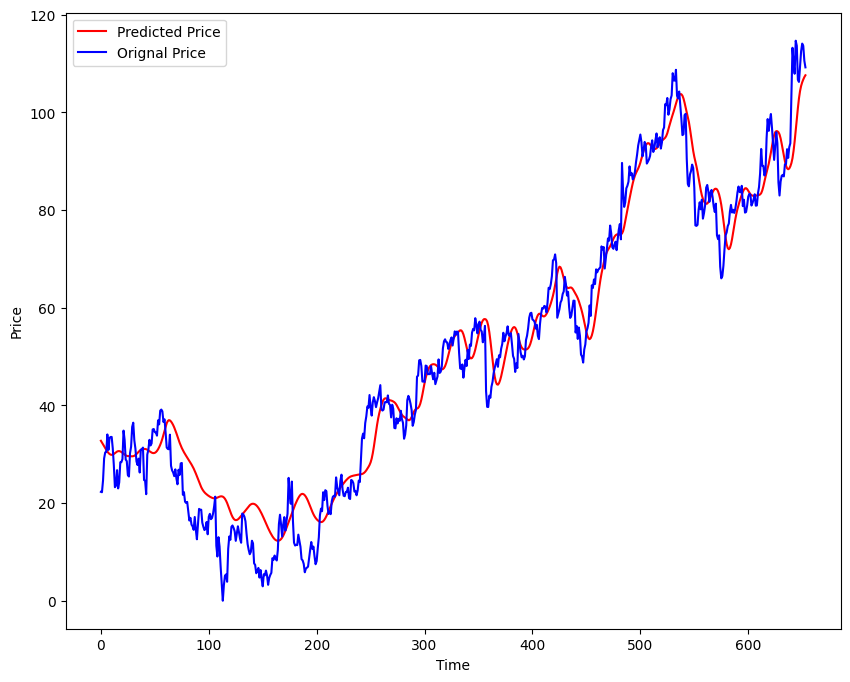

In [ ]:
plt.figure(figsize=(10,8))
plt.plot(y_predict,'r',label='Predicted Price')
plt.plot(y,'b',label='Orignal Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [ ]:
model.save('Stock_Prediction Model.keras')